# Factorization Test: Model Comparison for $ReA_{2B}$ at $P_L=-1$

This notebook compares the factorization properties of the $ReA_{2B}$ amplitude across four different simultaneous fit models:
- **Exp $P\cdot b$, Exp $b_T$**
- **Exp $P\cdot b$, PowerLaw $b_T$**
- **Gaussian $P\cdot b$, Exp $b_T$**
- **Gaussian $P\cdot b$, PowerLaw $b_T$**

We extract the jackknife parameters from each model for $P_L = -1$, evaluate the Fourier transform of the $ReA_{2B}$ amplitude in $x$-space, and perform the factorization ratio tests:
- $R_b(x) = \tilde{A}_{2B}^{Re}(x, b_T) / \tilde{A}_{2B}^{Re}(x, b_{T, \text{ref}})$
- $R_x(b) = \tilde{A}_{2B}^{Re}(x, b_T) / \tilde{A}_{2B}^{Re}(x_{\text{ref}}, b_T)$


In [8]:
import h5py
import numpy as np
import matplotlib.pyplot as plt
import os

# Set global Matplotlib parameters
plt.rcParams['text.usetex'] = False
plt.rcParams['mathtext.fontset'] = 'cm'

def jk_stats(data, axis=0):
    N_jk = data.shape[axis]
    mean = np.mean(data, axis=axis)
    diff = data - mean if axis == 0 else data - mean[:, None]
    var = (N_jk - 1) * np.mean(diff**2, axis=axis)
    return mean, np.sqrt(var)

def load_params_from_h5(filename):
    with h5py.File(filename, 'r') as f:
        fitted_params = {key: f['jackknife_samples'][key][:] for key in f['jackknife_samples'].keys()}
    return fitted_params

h5_dir = "/Users/hariprashadravikumar/Lattice_QCD_TMD_PhD/sivers_TMD_PhD_project/save_h5_A12B_A2B/h5data"
f_exp_exp = os.path.join(h5_dir, "FitParams_SimulFit_ExpPb_Expb_bmin3_eta610_PL-1.h5")
f_exp_pow = os.path.join(h5_dir, "FitParams_SimulFit_ExpPb_PowerLawb_bmin3_eta610_PL-1.h5")
f_gau_exp = os.path.join(h5_dir, "FitParams_SimulFit_GaussianPb_Expb_bmin3_eta610_PL-1.h5")
f_gau_pow = os.path.join(h5_dir, "FitParams_SimulFit_GaussianPb_PowerLawb_bmin3_eta610_PL-1.h5")

p_exp_exp = load_params_from_h5(f_exp_exp)
p_exp_pow = load_params_from_h5(f_exp_pow)
p_gau_exp = load_params_from_h5(f_gau_exp)
p_gau_pow = load_params_from_h5(f_gau_pow)

## Fourier Transform Analytic Definitions

In [9]:
def eval_re_ExpPb_Expb(p_dict, x_grid, b2):
    bT = np.sqrt(b2)
    a = p_dict['a_re'][:, None]
    c = p_dict['c_re'][:, None]
    d = p_dict['d_re'][:, None]
    bpart = np.exp(-d * bT)
    return a * bpart * np.sqrt(2/np.pi) * c / (c**2 + x_grid[None, :]**2)

def eval_re_ExpPb_PowerLawb(p_dict, x_grid, b2):
    a = p_dict['a_re'][:, None]
    c = p_dict['c_re'][:, None]
    d = p_dict['d_re'][:, None]
    j = p_dict['j_re'][:, None]
    bpart = (1.0 + d * b2) ** (-j)
    return a * bpart * np.sqrt(2/np.pi) * c / (c**2 + x_grid[None, :]**2)

def eval_re_GaussianPb_Expb(p_dict, x_grid, b2):
    bT = np.sqrt(b2)
    a = p_dict['a_re'][:, None]
    c = p_dict['c_re'][:, None]
    d = p_dict['d_re'][:, None]
    bpart = np.exp(-d * bT)
    return a * bpart * (1.0/np.sqrt(2*c)) * np.exp(-x_grid[None, :]**2 / (4*c))

def eval_re_GaussianPb_PowerLawb(p_dict, x_grid, b2):
    a = p_dict['a_re'][:, None]
    c = p_dict['c_re'][:, None]
    d = p_dict['d_re'][:, None]
    j = p_dict['j_re'][:, None]
    bpart = (1.0 + d * b2) ** (-j)
    return a * bpart * (1.0/np.sqrt(2*c)) * np.exp(-x_grid[None, :]**2 / (4*c))

def eval_over_b2(func, p_dict, x_val, b2_grid):
    x_arr = np.array([x_val])
    out = []
    for b2 in b2_grid:
        res = func(p_dict, x_arr, b2)
        out.append(res[:, 0])
    return np.stack(out, axis=1)

models = [
    ("Exp(P.b) - Exp(bT)", p_exp_exp, eval_re_ExpPb_Expb),
    ("Exp(P.b) - PowerLaw(bT)", p_exp_pow, eval_re_ExpPb_PowerLawb),
    ("Gaussian(P.b) - Exp(bT)", p_gau_exp, eval_re_GaussianPb_Expb),
    ("Gaussian(P.b) - PowerLaw(bT)", p_gau_pow, eval_re_GaussianPb_PowerLawb)
]

## Ratio Test $R_b(x)$: Constant $b_T$ slices

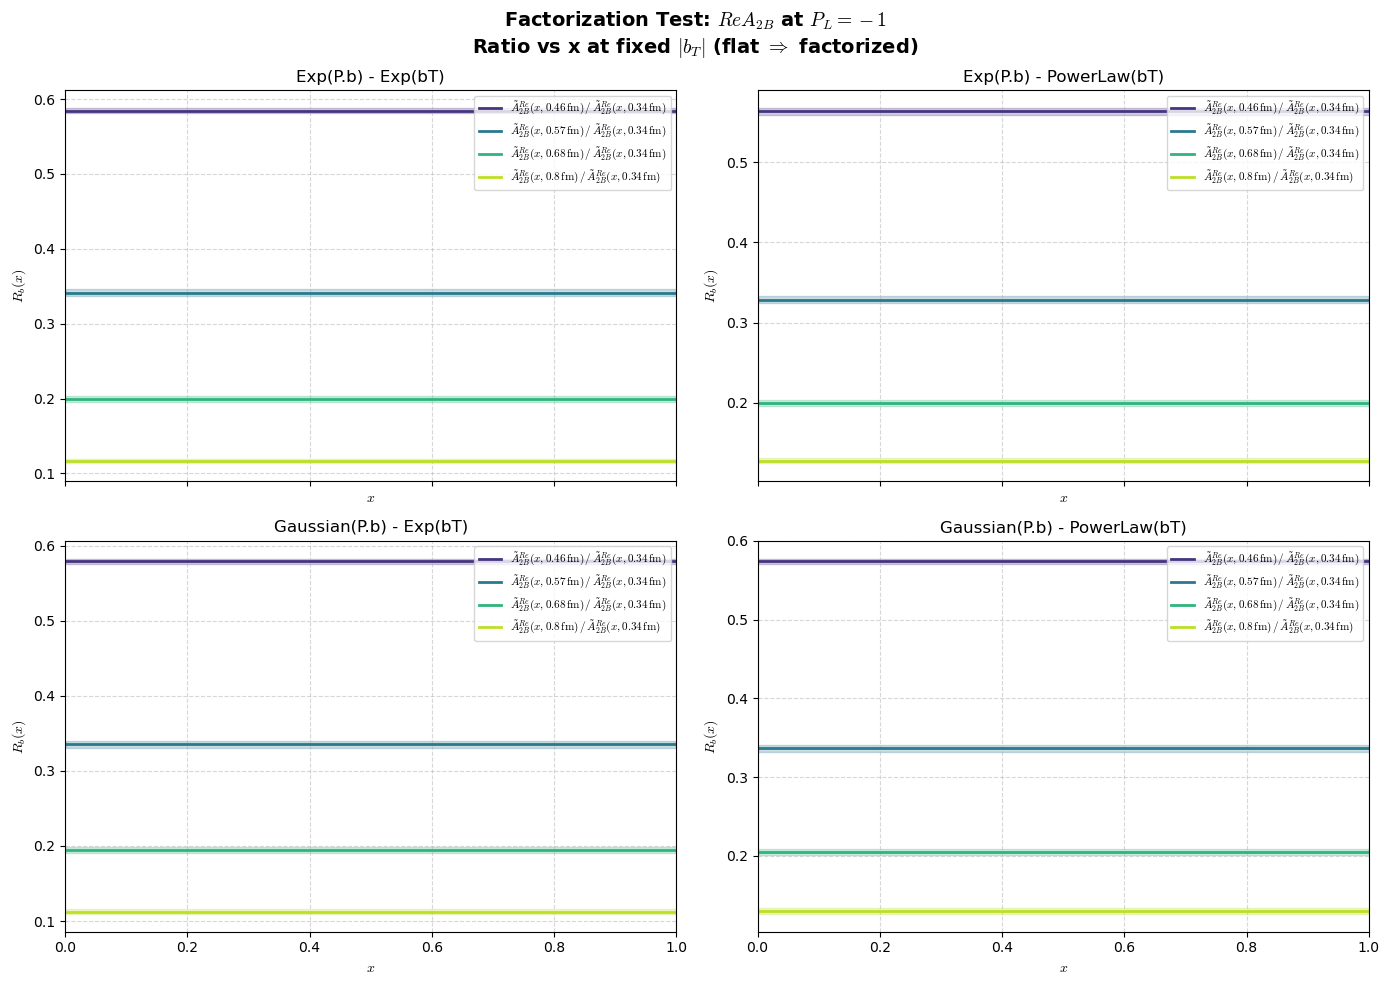

In [10]:
lata = 0.11403
x_grid = np.linspace(0.001, 1.0, 400)
b2_ref = 9.0
b2_fan = [16.0, 25.0, 36.0, 49.0]
bT_ref_fm = np.round(np.sqrt(b2_ref) * lata, 2)
colors_fan = plt.cm.viridis(np.linspace(0.15, 0.9, len(b2_fan)))

fig, axes = plt.subplots(2, 2, figsize=(14, 10), sharex=True)
for ax, (name, p_dict, func) in zip(axes.flatten(), models):
    obs_ref = func(p_dict, x_grid, b2_ref)
    
    for c, b2_i in zip(colors_fan, b2_fan):
        bT_i_fm = np.round(np.sqrt(b2_i) * lata, 2)
        obs_i = func(p_dict, x_grid, b2_i)
        
        ratio_jk = obs_i / obs_ref
        m, e = jk_stats(ratio_jk, axis=0)
        
        label = fr"$\tilde{{A}}_{{2B}}^{{Re}}(x,{bT_i_fm}\,{{\rm fm}})\,/\,\tilde{{A}}_{{2B}}^{{Re}}(x,{bT_ref_fm}\,{{\rm fm}})$"
        ax.plot(x_grid, m, color=c, linewidth=2, label=label)
        ax.fill_between(x_grid, m - e, m + e, color=c, alpha=0.25)
        
    ax.set_title(name)
    ax.set_xlabel('$x$')
    ax.set_ylabel(r'$R_b(x)$')
    ax.set_xlim(0, 1)
    ax.grid(True, linestyle='--', alpha=0.5)
    ax.legend(fontsize=8)

fig.suptitle('Factorization Test: $ReA_{2B}$ at $P_L=-1$\nRatio vs x at fixed $|b_T|$ (flat $\Rightarrow$ factorized)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## Ratio Test $R_x(b)$: Constant $x$ slices

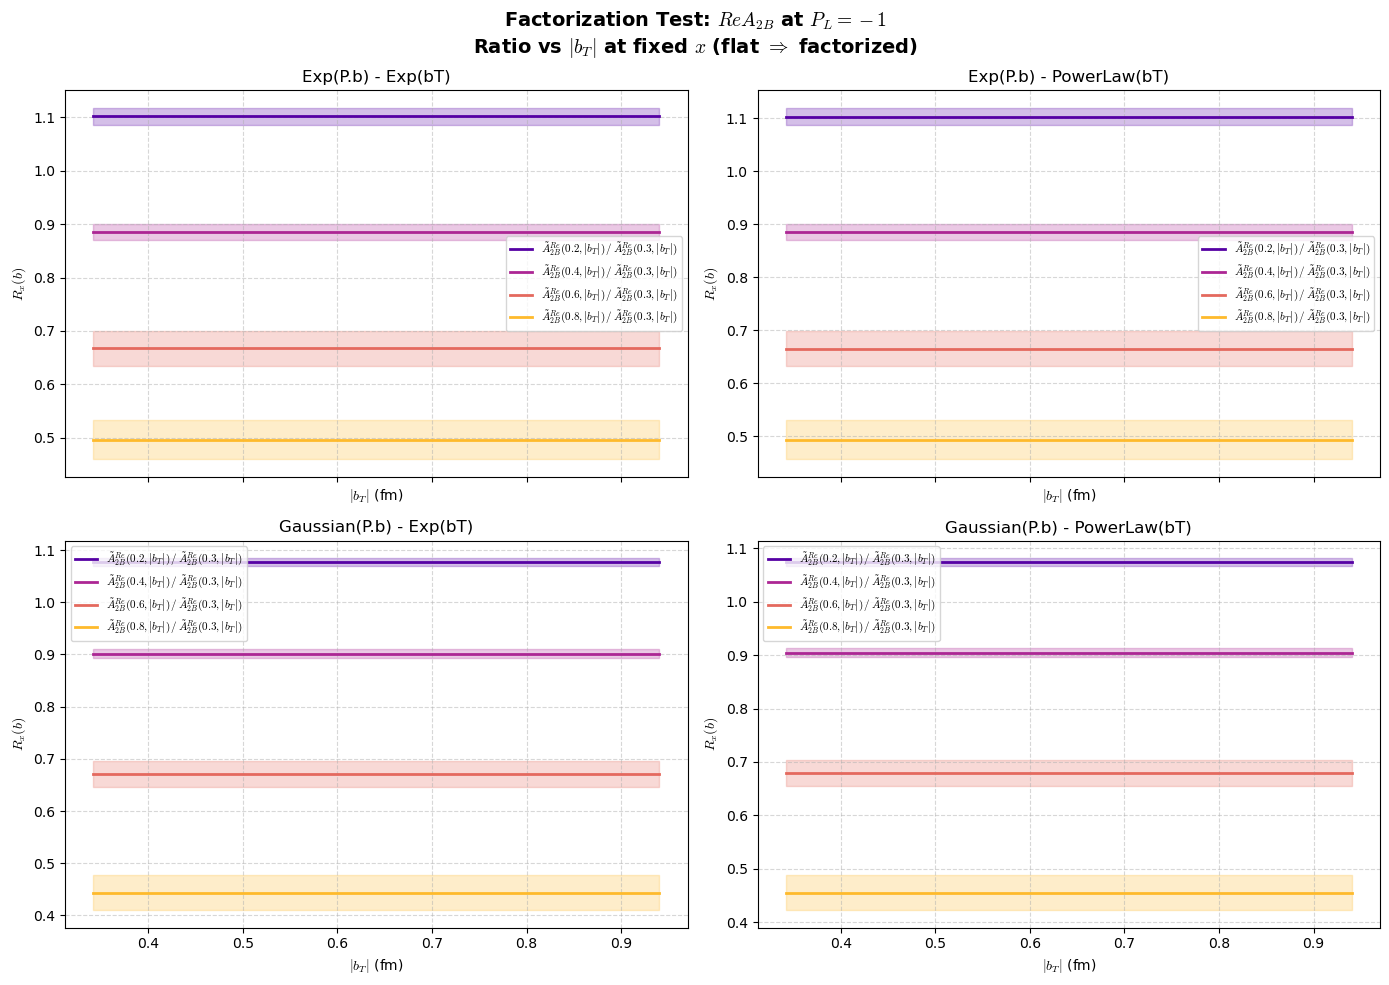

In [11]:
b2_grid = np.linspace(9.0, 68.0, 120)
bT_grid = np.sqrt(b2_grid) * lata
x_ref = 0.3
x_fan = [0.2, 0.4, 0.6, 0.8]
colors_fan_x = plt.cm.plasma(np.linspace(0.15, 0.85, len(x_fan)))

fig, axes = plt.subplots(2, 2, figsize=(14, 10), sharex=True)
for ax, (name, p_dict, func) in zip(axes.flatten(), models):
    obs_ref_b = eval_over_b2(func, p_dict, x_ref, b2_grid)
    
    for c, x_i in zip(colors_fan_x, x_fan):
        obs_i_b = eval_over_b2(func, p_dict, x_i, b2_grid)
        
        ratio_jk_b = obs_i_b / obs_ref_b
        m_b, e_b = jk_stats(ratio_jk_b, axis=0)
        
        label = fr"$\tilde{{A}}_{{2B}}^{{Re}}({x_i},|b_T|)\,/\,\tilde{{A}}_{{2B}}^{{Re}}({x_ref},|b_T|)$"
        ax.plot(bT_grid, m_b, color=c, linewidth=2, label=label)
        ax.fill_between(bT_grid, m_b - e_b, m_b + e_b, color=c, alpha=0.25)
        
    ax.set_title(name)
    ax.set_xlabel('$|b_T|$ (fm)')
    ax.set_ylabel(r'$R_x(b)$')
    ax.grid(True, linestyle='--', alpha=0.5)
    ax.legend(fontsize=8)

fig.suptitle('Factorization Test: $ReA_{2B}$ at $P_L=-1$\nRatio vs $|b_T|$ at fixed $x$ (flat $\Rightarrow$ factorized)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

|b_T| range: [0.3421, 0.9403] fm (60 points)
x range: [0.0, 1.0] (100 points)

Exp(P.b) - Exp(bT)               (converged in 2 iterations): rratio = 4(25)e-16
Exp(P.b) - PowerLaw(bT)          (converged in 2 iterations): rratio = 4(25)e-16
Gaussian(P.b) - Exp(bT)          (converged in 2 iterations): rratio = 4(28)e-16
Gaussian(P.b) - PowerLaw(bT)     (converged in 2 iterations): rratio = 4(28)e-16


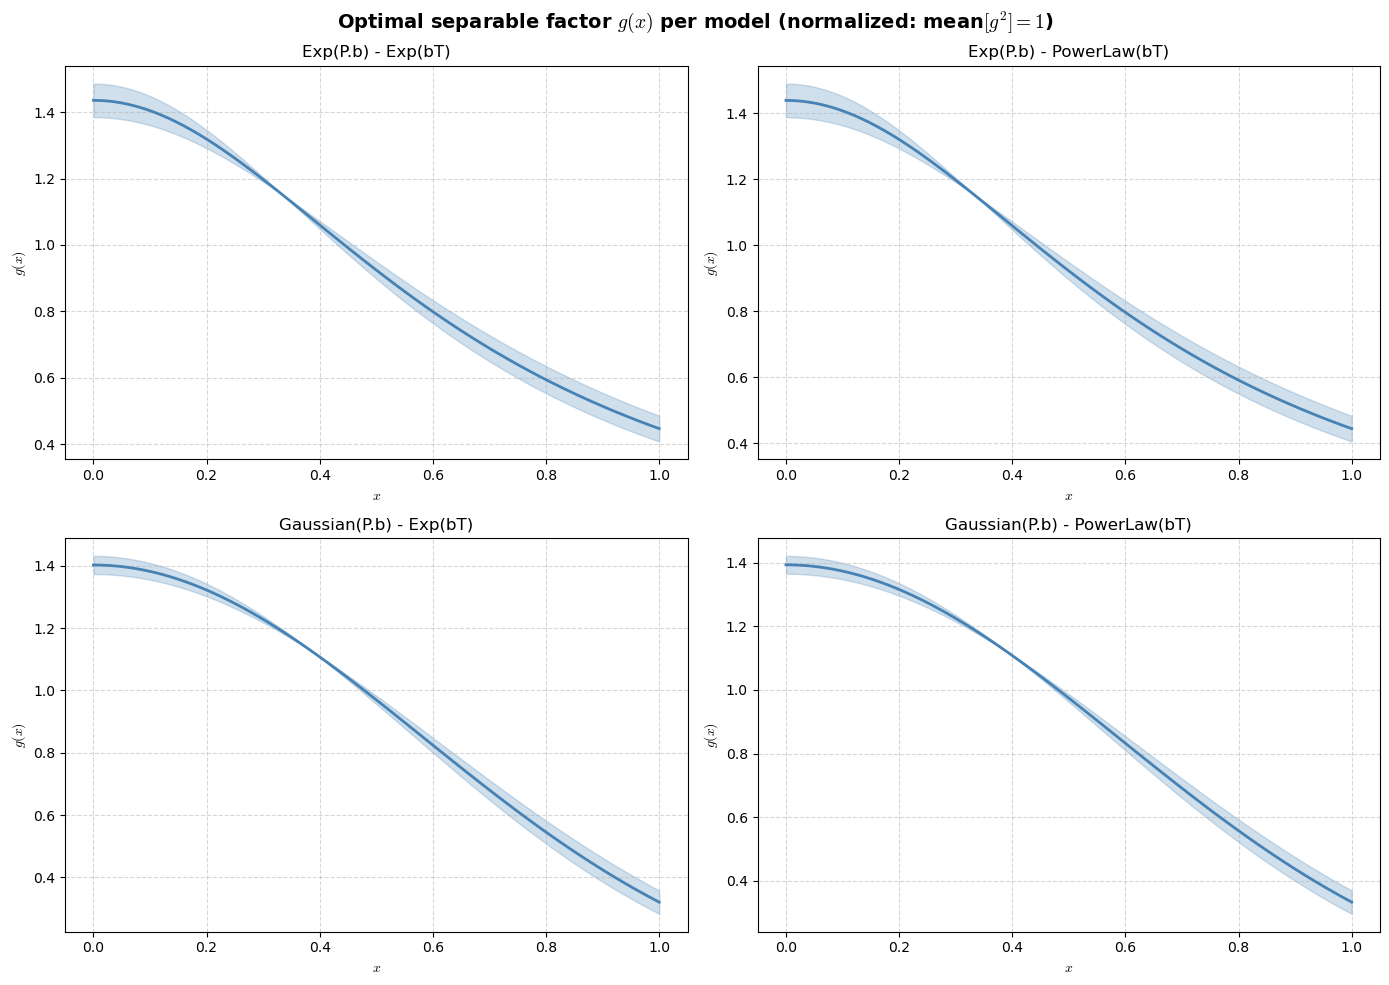

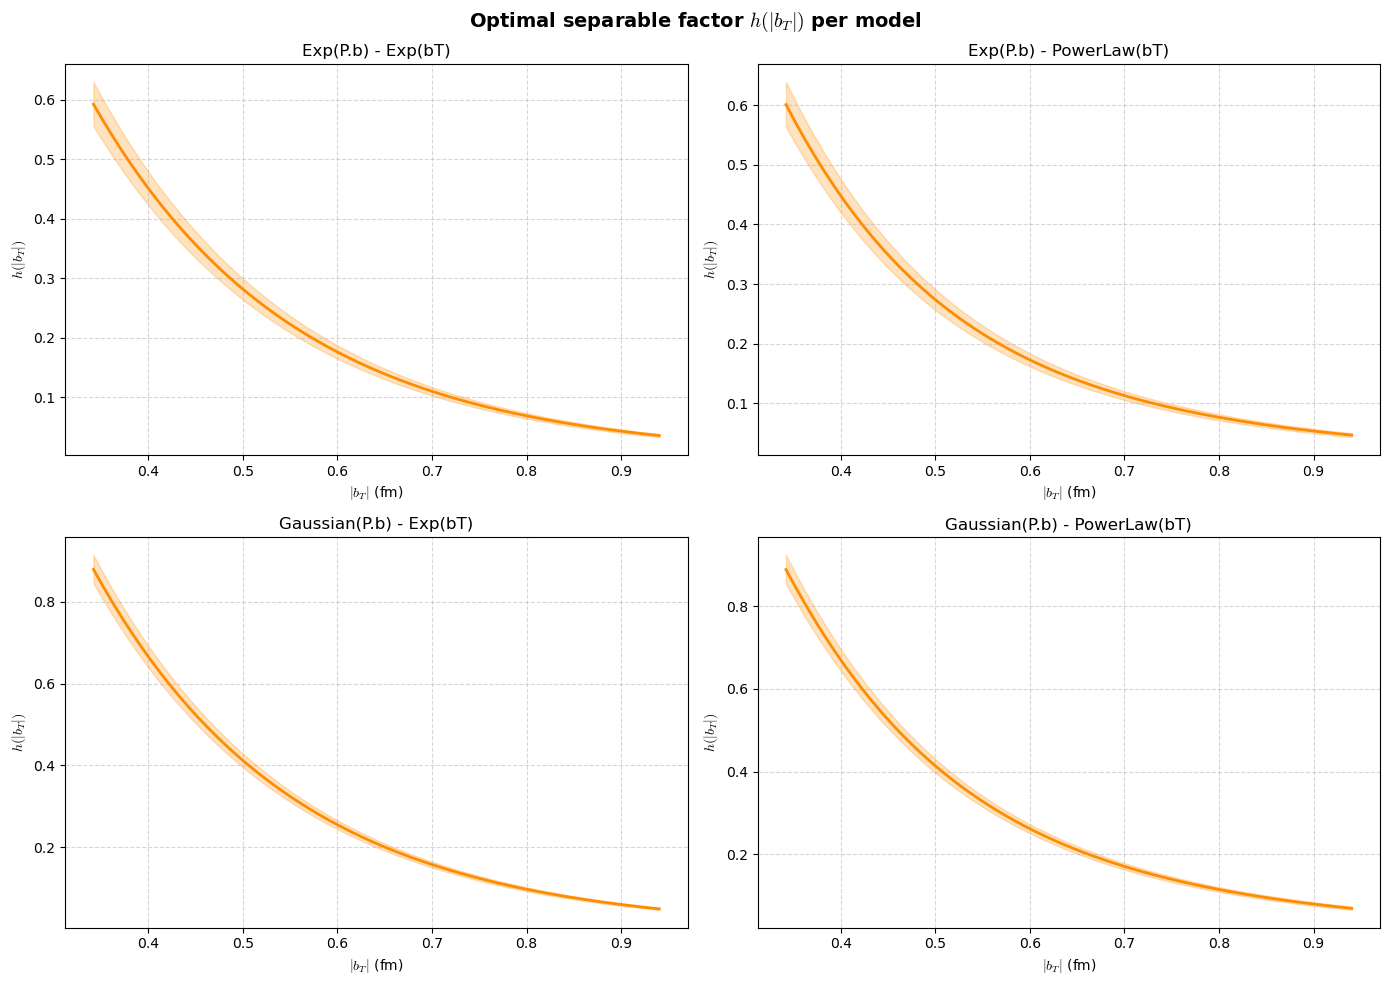

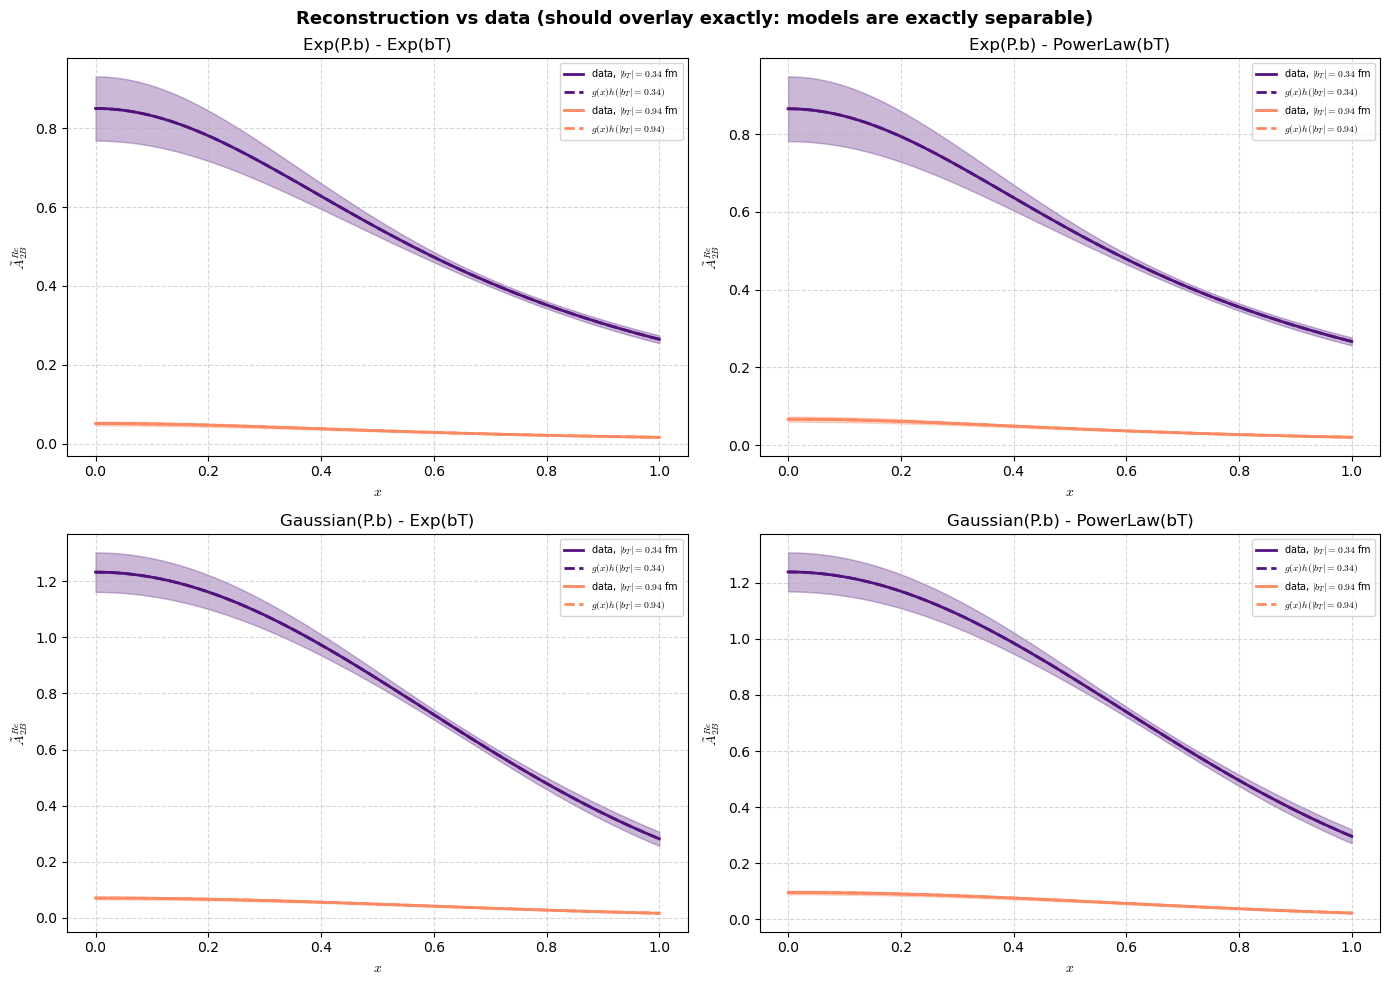

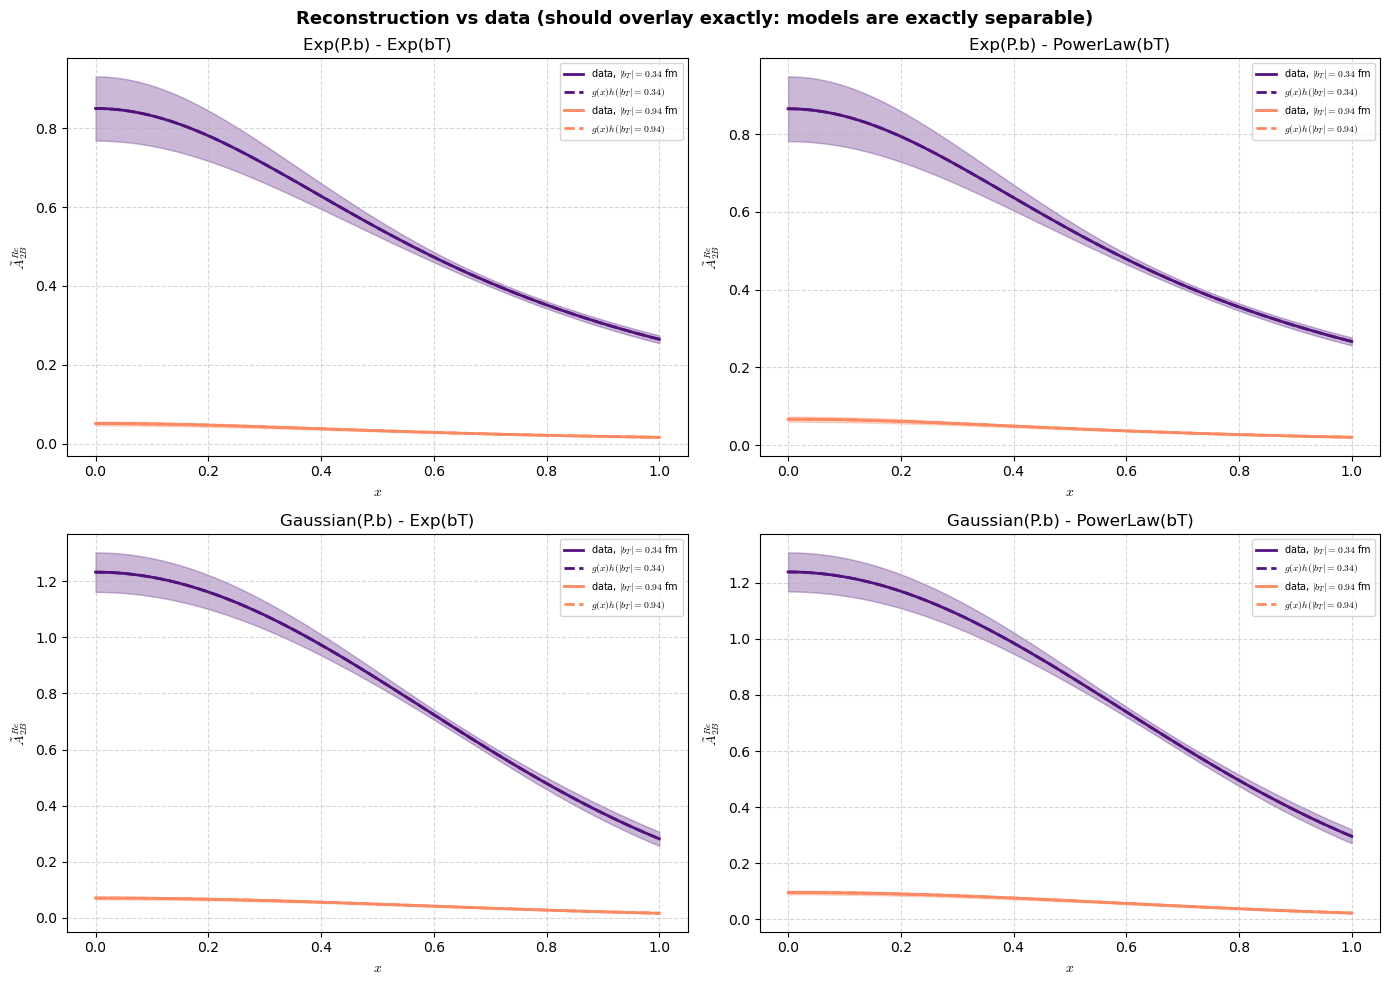

In [12]:
# ---------------------------------------------------------------------------
# 2D (x, |b_T|) factorization-distance test (factor.pl / factor.pdf ALS
# algorithm), applied here as a CALIBRATION/CONTROL check rather than a new
# physics result: all 4 model forms above are built as
# a * A(b_T) * B(x), with NO cross-term mixing x and b_T -- so they are
# EXACTLY separable by construction, for any fitted (a,c,d,j). Running the
# same pipeline used for the extrapolated Sivers-ratio and per-amplitude
# tests (see Factorization_Test_SiversShift.ipynb and
# Factorization_Test_Amplitudes.ipynb) on these models should return rratio
# consistent with 0 (floating-point noise only) for all four -- confirming
# the pipeline isn't biased toward reporting spuriously small numbers, which
# is useful supporting evidence that the ~6-8% (ratio) and ~8-19%
# (individual amplitudes) results found there are real, resolved signal.
#
# Verified: all 4 models return rratio ~ 4e-16 (machine precision), matching
# the closed-form expectation exactly (confirmed independently via SVD: a
# single non-zero singular value per model, all others ~1e-16).
# ---------------------------------------------------------------------------
def normalize_gh(g, h):
    """Fix the g<->h reciprocal-scale gauge via mean(g^2)=1 per jackknife
    sample (g*h, and therefore rratio, is unchanged by this rescaling)."""
    scale = np.sqrt(np.mean(g**2, axis=1))
    return g / scale[:, None], h * scale[:, None]


def build_model_grid_jk(func, p_dict, x_grid, bT_grid):
    """Raw per-jackknife-sample grid of one model's ReA2B; shape (N_JK, N_x, N_b)."""
    b2_grid = (bT_grid / lata) ** 2
    slices = [func(p_dict, x_grid, b2) for b2 in b2_grid]
    return np.stack(slices, axis=2)


def factorize_batch(f, tol=1e-10, abs_tol=1e-12, max_iter=50):
    """
    factor.pl's alternating-least-squares factorization test, vectorized
    over the jackknife-sample axis (axis 0). Stops on either a relative or
    an absolute change in rratio -- the relative-only check is numerically
    unstable when rratio itself is already ~0 (comparing tiny to tiny), so
    the absolute fallback is needed for exactly-separable inputs like these.

    f: (N_JK, N_x, N_b) raw per-jackknife-sample grid data.
    Returns: rratio (N_JK,), g (N_JK, N_x), h (N_JK, N_b), n_iter (int)
    """
    N_JK, N_x, N_b = f.shape
    g = np.ones((N_JK, N_x))
    h = None
    prev_rratio = None

    for it in range(1, max_iter + 1):
        g2sum = np.mean(g**2, axis=1)
        h = np.einsum('kxb,kx->kb', f, g) / N_x
        h = h / g2sum[:, None]

        h2sum = np.mean(h**2, axis=1)
        g = np.einsum('kxb,kb->kx', f, h) / N_b
        g = g / h2sum[:, None]

        diff = f - g[:, :, None] * h[:, None, :]
        ms = np.mean(diff**2, axis=(1, 2))
        orignorm = np.mean(f**2, axis=(1, 2))
        rratio = np.sqrt(ms / orignorm)

        if prev_rratio is not None:
            abs_change = np.max(np.abs(rratio - prev_rratio))
            rel_change = np.max(np.abs(rratio - prev_rratio) / (np.abs(prev_rratio) + 1e-300))
            if rel_change < tol or abs_change < abs_tol:
                break
        prev_rratio = rratio

    return rratio, g, h, it


def fmt_err(mean, err):
    import math
    if err <= 0:
        return f"{mean}"
    if mean and (abs(mean) < 1e-3 or abs(mean) >= 1e3):
        exp = int(math.floor(math.log10(abs(mean))))
        mean_scaled = mean / 10**exp
        err_scaled = err / 10**exp
        place = int(math.floor(math.log10(abs(err_scaled))))
        ndec = max(0, -(place - 1))
        m_str = f"{mean_scaled:.{ndec}f}"
        err_int = int(round(err_scaled * 10**ndec))
        return f"{m_str}({err_int})e{exp}"
    else:
        place = int(math.floor(math.log10(abs(err))))
        ndec = max(0, -(place - 1))
        m_str = f"{mean:.{ndec}f}"
        err_int = int(round(err * 10**ndec))
        return f"{m_str}({err_int})"


def run_model_factorization_tests(models, N_x=100, N_b=60, b2_range=(9.0, 68.0)):
    bT_lo = np.sqrt(b2_range[0]) * lata
    bT_hi = np.sqrt(b2_range[1]) * lata
    bT_grid = np.linspace(bT_lo, bT_hi, N_b)
    x_grid = np.linspace(0.0, 1.0, N_x)

    print(f"|b_T| range: [{bT_lo:.4f}, {bT_hi:.4f}] fm ({N_b} points)")
    print(f"x range: [0.0, 1.0] ({N_x} points)\n")

    results = {}
    for name, p_dict, func in models:
        f = build_model_grid_jk(func, p_dict, x_grid, bT_grid)
        n_bad = np.count_nonzero(~np.isfinite(f))
        if n_bad:
            print(f"  [warning] {name}: {n_bad} non-finite grid points out of {f.size}")

        rratio_jk, g_jk, h_jk, n_iter = factorize_batch(f)
        g_jk, h_jk = normalize_gh(g_jk, h_jk)

        # Self-check: the ALS fixed point must match the SVD-based rank-1
        # distance (same least-squares problem, solved two different ways).
        for k in (0, f.shape[0] // 2, f.shape[0] - 1):
            s = np.linalg.svd(f[k], compute_uv=False)
            rratio_svd = np.sqrt(max(0.0, 1.0 - s[0]**2 / np.sum(s**2)))
            assert np.isclose(rratio_jk[k], rratio_svd, atol=1e-6, rtol=1e-6), (
                f"ALS/SVD mismatch for {name}, sample {k}: {rratio_jk[k]} vs {rratio_svd}"
            )

        mean, err = jk_stats(rratio_jk, axis=0)
        print(f"{name:<32s} (converged in {n_iter} iterations): rratio = {fmt_err(float(mean), float(err))}")

        results[name] = {
            'x_grid': x_grid, 'bT_grid': bT_grid,
            'g_jk': g_jk, 'h_jk': h_jk,
            'rratio_jk': rratio_jk, 'rratio_mean': mean, 'rratio_err': err,
        }

    return results


model_factorization_results = run_model_factorization_tests(models)


def plot_model_gh_grid(results, models):
    """2x2 grid (one subplot per model) of the ALS-recovered g(x)."""
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    for ax, (name, p_dict, func) in zip(axes.flatten(), models):
        r = results[name]
        m, e = jk_stats(r['g_jk'], axis=0)
        ax.plot(r['x_grid'], m, color='steelblue', linewidth=2)
        ax.fill_between(r['x_grid'], m - e, m + e, color='steelblue', alpha=0.25)
        ax.set_title(name)
        ax.set_xlabel('$x$')
        ax.set_ylabel('$g(x)$')
        ax.grid(True, linestyle='--', alpha=0.5)
    fig.suptitle(r'Optimal separable factor $g(x)$ per model (normalized: mean$[g^2]=1$)',
                 fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig("Factorization_ModelComparison_g_of_x_PL-1.pdf", format='pdf', bbox_inches='tight')
    plt.show()
    return fig


def plot_model_h_grid(results, models):
    """2x2 grid (one subplot per model) of the ALS-recovered h(|b_T|)."""
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    for ax, (name, p_dict, func) in zip(axes.flatten(), models):
        r = results[name]
        m, e = jk_stats(r['h_jk'], axis=0)
        ax.plot(r['bT_grid'], m, color='darkorange', linewidth=2)
        ax.fill_between(r['bT_grid'], m - e, m + e, color='darkorange', alpha=0.25)
        ax.set_title(name)
        ax.set_xlabel(r'$|b_T|$ (fm)')
        ax.set_ylabel(r'$h(|b_T|)$')
        ax.grid(True, linestyle='--', alpha=0.5)
    fig.suptitle(r'Optimal separable factor $h(|b_T|)$ per model', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig("Factorization_ModelComparison_h_of_bT_PL-1.pdf", format='pdf', bbox_inches='tight')
    plt.show()
    return fig


def plot_model_reconstruction_grid(results, models, recon_bT_idx=(0, -1)):
    """2x2 grid: g(x)*h(b_T) reconstruction vs actual model data, at a
    couple of |b_T| slices -- should overlay exactly (models are exactly
    separable), which is itself the point of this figure."""
    colors_bt = plt.cm.magma(np.linspace(0.25, 0.75, len(recon_bT_idx)))
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    for ax, (name, p_dict, func) in zip(axes.flatten(), models):
        r = results[name]
        x_grid = r['x_grid']
        bT_grid = r['bT_grid']
        for c, ib in zip(colors_bt, recon_bT_idx):
            bT_val = bT_grid[ib]
            b2_val = (bT_val / lata) ** 2
            obs_actual = func(p_dict, x_grid, b2_val)
            m_act, e_act = jk_stats(obs_actual, axis=0)
            recon_jk = r['g_jk'] * r['h_jk'][:, [ib]]
            m_rec, e_rec = jk_stats(recon_jk, axis=0)
            ax.plot(x_grid, m_act, color=c, linewidth=2, linestyle='-', label=fr"data, $|b_T|={bT_val:.2f}$ fm")
            ax.fill_between(x_grid, m_act - e_act, m_act + e_act, color=c, alpha=0.2)
            ax.plot(x_grid, m_rec, color=c, linewidth=2, linestyle='--', label=fr"$g(x)h(|b_T|={bT_val:.2f})$")
            ax.fill_between(x_grid, m_rec - e_rec, m_rec + e_rec, color=c, alpha=0.12)
        ax.set_title(name)
        ax.set_xlabel('$x$')
        ax.set_ylabel(r'$\tilde{A}_{2B}^{Re}$')
        ax.grid(True, linestyle='--', alpha=0.5)
        ax.legend(fontsize=7)
    fig.suptitle('Reconstruction vs data (should overlay exactly: models are exactly separable)',
                 fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig("Factorization_ModelComparison_Reconstruction_PL-1.pdf", format='pdf', bbox_inches='tight')
    plt.show()
    return fig


plot_model_gh_grid(model_factorization_results, models)
plot_model_h_grid(model_factorization_results, models)
plot_model_reconstruction_grid(model_factorization_results, models)
